# Model Training & Comparative Analysis

In questo notebook addestreremo 4 diversi modelli di classificazione sul dataset processato e li valuteremo sul **GUIDE Test Set**. 

**Obiettivo:** Identificare il modello migliore per predire se un incidente è un **True Positive** (Minaccia Reale).

**Modelli:**
1.  **Decision Tree**: Modello baseline interpretabile.
2.  **Random Forest**: Modello ensemble robusto.
3.  **XGBoost**: Gradient Boosting (spesso SOTA su dati tabulari).
4.  **Feed Forward Neural Network (MLP)**: Rete neurale multistrato.

**Strategia Anti-Leakage:**
*   Il training avviene **solo** su `train_final.csv` (che viene splittato internamente in Train/Validation).
*   Il file `test_final.csv` (derivato da `GUIDE_Test`) viene usato **solo alla fine** per la valutazione finale. Nessuna decisione di training viene presa guardando questi dati.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Modelli
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Metriche e Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Configurazioni
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data/processed_final'

print("Librerie caricate.")

Librerie caricate.


## 1. Caricamento e Preparazione Dati

In [2]:
# Carichiamo i dataset generati dalla pipeline precedente
print("Caricamento dati...")

# Possiamo scegliere tra 'train_final_imbalanced.csv' e 'train_final_balanced.csv'
# Per questa comparazione usiamo il bilanciato per evitare bias verso la classe 0
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_final_balanced.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_final.csv'))

# Selezioniamo le feature (escludiamo ID)
features_to_drop = ['IncidentId', 'Target']

# X e y per Training
X_train_full = train_df.drop(columns=features_to_drop, errors='ignore')
y_train_full = train_df['Target']

# X e y per Test (GUIDE_Test)
X_test_final = test_df.drop(columns=features_to_drop, errors='ignore')
y_test_final = test_df['Target']

# Rimuoviamo eventuali righe con Target NaN nel test set (se ce ne sono)
valid_test_mask = y_test_final.notna()
X_test_final = X_test_final[valid_test_mask]
y_test_final = y_test_final[valid_test_mask]

print(f"Training Set (Balanced): {X_train_full.shape}")
print(f"Test Set (Hold-out):     {X_test_final.shape}")

Caricamento dati...
Training Set (Balanced): (258686, 39)
Test Set (Hold-out):     (236267, 39)


### 1.1 Scaling e Split di Validazione
Le reti neurali richiedono dati scalati. Gli alberi non ne hanno bisogno, ma non ne soffrono. Scaliamo tutto per uniformità.
Creiamo anche un validation set interno dal training per monitorare l'addestramento.

In [3]:
# Split Train / Validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("Dati scalati e splittati.")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples:   {X_val.shape[0]}")

Dati scalati e splittati.
Train samples: 206948
Val samples:   51738


## 2. Addestramento Modelli

In [4]:
# Dizionario per salvare i modelli addestrati e i risultati
models = {}
results = {}

def train_and_evaluate(name, model, X_tr, y_tr, X_v, y_v):
    print(f"\nAddestramento {name}...")
    model.fit(X_tr, y_tr)
    
    # Predizioni su Validation
    preds = model.predict(X_v)
    probs = model.predict_proba(X_v)[:, 1]
    
    print(f"{name} - Validation F1: {f1_score(y_v, preds):.4f}")
    print(f"{name} - Validation AUC: {roc_auc_score(y_v, probs):.4f}")
    
    return model

### 2.1 Decision Tree

In [5]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
models['DecisionTree'] = train_and_evaluate('DecisionTree', dt_model, X_train, y_train, X_val, y_val)


Addestramento DecisionTree...
DecisionTree - Validation F1: 0.8765
DecisionTree - Validation AUC: 0.9508


### 2.2 Random Forest

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
models['RandomForest'] = train_and_evaluate('RandomForest', rf_model, X_train, y_train, X_val, y_val)


Addestramento RandomForest...
RandomForest - Validation F1: 0.8892
RandomForest - Validation AUC: 0.9576


### 2.3 XGBoost

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=6, 
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
models['XGBoost'] = train_and_evaluate('XGBoost', xgb_model, X_train, y_train, X_val, y_val)


Addestramento XGBoost...
XGBoost - Validation F1: 0.9044
XGBoost - Validation AUC: 0.9695


### 2.4 Feed Forward Neural Network (MLP)

In [13]:
# Usiamo MLPClassifier di Sklearn per semplicità
# Architettura: 2 layer nascosti (128, 64 neuroni)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    alpha=0.0001, 
    batch_size=256,
    learning_rate_init=0.005,
    max_iter=50,
    random_state=42,
    early_stopping=True
)

# Nota: per MLP usiamo i dati scalati
models['MLP'] = train_and_evaluate('MLP', mlp_model, X_train_scaled, y_train, X_val_scaled, y_val)


Addestramento MLP...
MLP - Validation F1: 0.8660
MLP - Validation AUC: 0.9447


## 3. Valutazione Finale su GUIDE_Test

Ora testiamo i modelli sul dataset di test reale (`GUIDE_Test`), che non hanno mai visto.

In [14]:
final_metrics = []

print("Valutazione sul Test Set Finale (GUIDE_Test)...")

for name, model in models.items():
    # Scegli il dataset corretto (scalato per MLP, normale per altri)
    X_target = X_test_scaled if name == 'MLP' else X_test_final
    
    # Predizioni
    y_pred = model.predict(X_target)
    y_prob = model.predict_proba(X_target)[:, 1]
    
    # Calcolo Metriche
    acc = accuracy_score(y_test_final, y_pred)
    prec = precision_score(y_test_final, y_pred)
    rec = recall_score(y_test_final, y_pred)
    f1 = f1_score(y_test_final, y_pred)
    auc = roc_auc_score(y_test_final, y_prob)
    
    final_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
    # Salva predizioni per analisi successive
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob}

# Tabella Comparativa
metrics_df = pd.DataFrame(final_metrics).set_index('Model')
print("\n--- Risultati Finali ---")
display(metrics_df.style.background_gradient(cmap='viridis', axis=0))

Valutazione sul Test Set Finale (GUIDE_Test)...

--- Risultati Finali ---


,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
DecisionTree,0.808619,0.575573,0.899407,0.701941,0.928863
RandomForest,0.848227,0.650108,0.853764,0.738147,0.936718
XGBoost,0.879192,0.709852,0.875842,0.784159,0.956316
MLP,0.830929,0.622842,0.824490,0.709619,0.919425


## 4. Visualizzazioni e Confronto

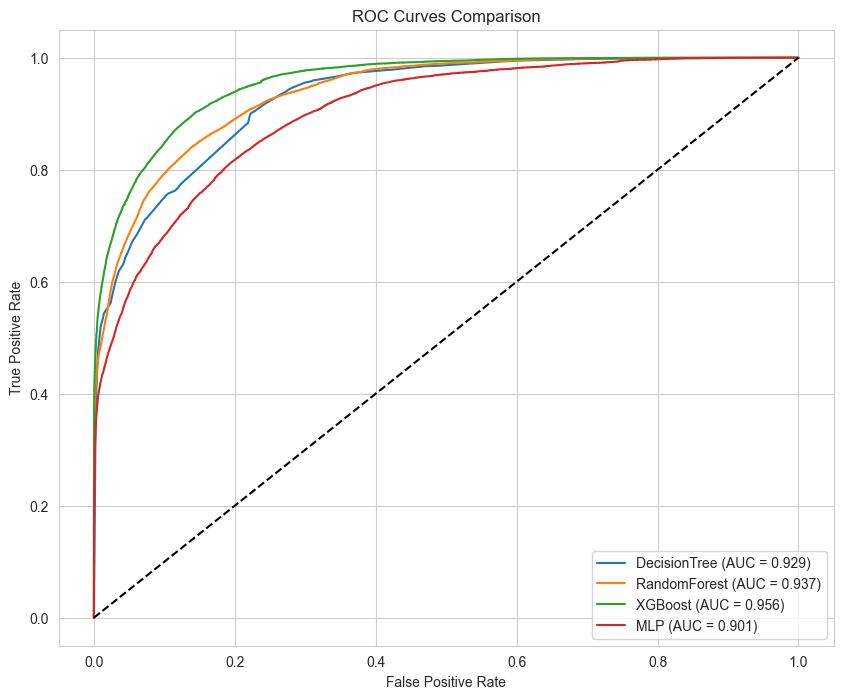

In [10]:
# 1. ROC Curves
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_final, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_final, res['y_prob']):.3f})")

plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

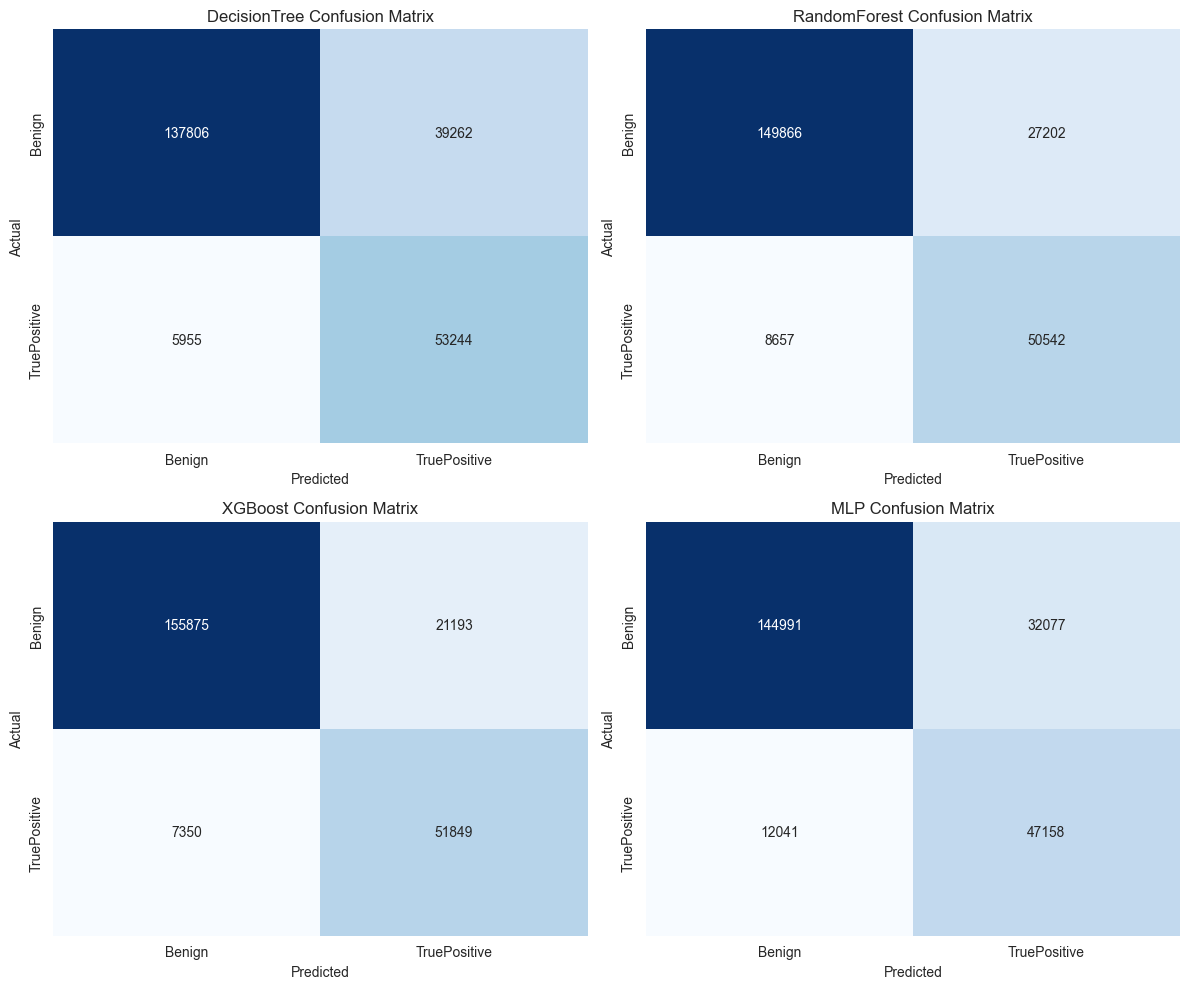

In [11]:
# 2. Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_final, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Benign', 'TruePositive'])
    axes[i].set_yticklabels(['Benign', 'TruePositive'])

plt.tight_layout()
plt.show()

## 5. Feature Importance (XGBoost)
Vediamo quali feature sono state più determinanti per il modello migliore (spesso XGBoost).

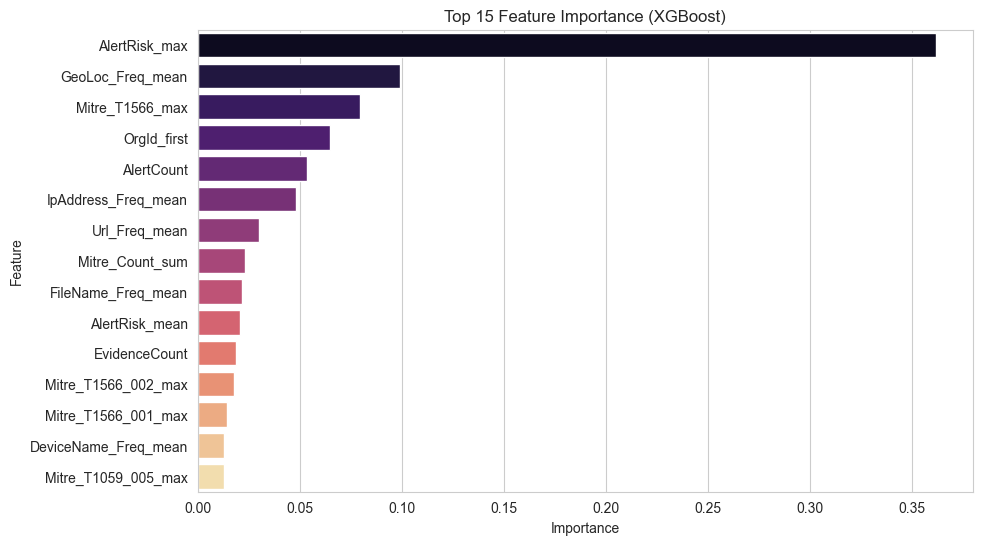

In [12]:
importance = models['XGBoost'].feature_importances_
feat_names = X_train.columns

feat_imp = pd.DataFrame({'Feature': feat_names, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.show()